In [1]:
import time
import cv2
import numpy as np
from ugot import ugot

from IPython.display import display, clear_output, Image

got = ugot.UGOT()
got.initialize("192.168.1.29")
got.load_models(["color_recognition"])

got.open_camera()

192.168.1.29:50051


In [2]:
def color_rec():
    color_info = got.get_color_total_info()

    frame = got.read_camera_data()
    if frame is not None:
        nparr = np.frombuffer(frame, np.uint8)
        data = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if color_info[0]:
            cv2.putText(data, color_info[0], (50, 40), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

            c_x = color_info[2]
            c_y = color_info[3]
            h = color_info[4]
            w = color_info[5]

            cv2.rectangle(data, (int(c_x - w / 2), int(c_y - h / 2)), 
                            (int(c_x + w / 2), int(c_y + h / 2)), (0, 0, 255), 2)
            

        _, jpeg = cv2.imencode('.jpg', data)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

        return color_info[0]

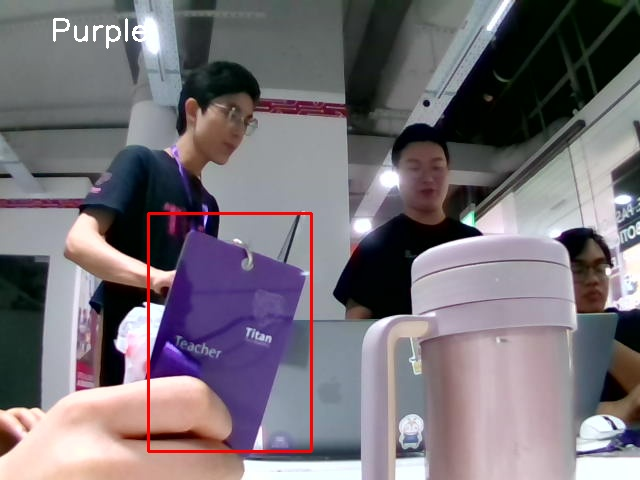

Done


In [4]:
try:
    while True:
        color = color_rec()

        if color == "Purple":
            got.screen_display_background(2)
        elif color == "Blue":
            got.screen_display_background(8)
        elif color == "Green":
            got.screen_display_background(6)
            time.sleep(1)
            break
        else:
            got.screen_display_background(0)
except KeyboardInterrupt:
    # cv2.destroyAllWindows()
    print("Done")